# Question 2: How do political attitudes and Human value priorities differ across generational cohorts in the Pre and post pandemic landscape?

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
import statsmodels.api as sm

# Load the already cleaned and MRAT-corrected data
df = pd.read_csv('ess_final_analysis.csv')

print(df.head())

  generation  yrbrn  lrscale  stflife  trstprl  gincdif  mrat_score  \
0      Gen X   1975        9      NaN      5.0      5.0    4.952381   
1    Boomers   1951        5      NaN      NaN      4.0    3.809524   
2      Gen X   1978        5      NaN      6.0      4.0    3.952381   
3    Boomers   1947        5      NaN      NaN      4.0    4.238095   
4    Boomers   1954        3      NaN      6.0      4.0    5.000000   

   Universalism_centered  Benevolence_centered  Tradition_centered  \
0              -0.619048              0.047619            0.547619   
1               0.190476              0.690476           -0.309524   
2               0.047619              0.547619            0.047619   
3               1.095238              0.761905            0.761905   
4               1.000000              1.000000            1.000000   

   Security_centered  Conformity_centered  Self-Direction_centered  \
0           0.047619             0.047619                 0.547619   
1           

In [ ]:
# Define our 10 MRAT-centered features 
schwartz_values = [
    'Universalism', 'Benevolence', 'Tradition', 'Security', 
    'Conformity', 'Self-Direction', 'Stimulation', 'Hedonism', 
    'Achievement', 'Power'
]
features = [f'{v}_centered' for v in schwartz_values]
print(f"Features for ALS: {features}")

# Create 'df_clean' by dropping NaNs of from 'df'
df_clean = df.dropna(subset=features + ['lrscale', 'generation']).copy()
print(f"Data cleaned. Rows remaining: {len(df_clean)}")


Features for ALS: ['Universalism_centered', 'Benevolence_centered', 'Tradition_centered', 'Security_centered', 'Conformity_centered', 'Self-Direction_centered', 'Stimulation_centered', 'Hedonism_centered', 'Achievement_centered', 'Power_centered']
Data cleaned. Rows remaining: 73205


In [10]:
# 4. The ALS Model (TruncatedSVD)
als = TruncatedSVD(n_components=2, random_state=42)
latent_factors = als.fit_transform(df_clean[features])

# Save the new coordinates back to the clean dataframe
df_clean['Factor_1'] = latent_factors[:, 0]
df_clean['Factor_2'] = latent_factors[:, 1]

print(f"✅ ALS Complete. Explained Variance: {als.explained_variance_ratio_.sum() * 100:.2f}%\n")

✅ ALS Complete. Explained Variance: 45.79%



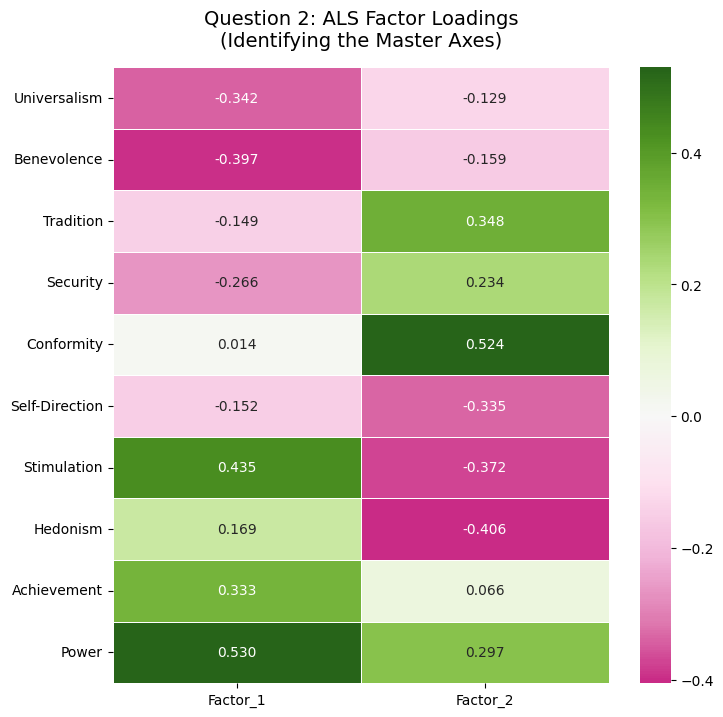

In [11]:
# 5. Plot the Loadings Heatmap
loadings = pd.DataFrame(
    als.components_.T, 
    columns=['Factor_1', 'Factor_2'], 
    index=schwartz_values
)

plt.figure(figsize=(8, 8))
sns.heatmap(loadings, annot=True, cmap='PiYG', center=0, fmt=".3f", linewidths=.5)
plt.title('Question 2: ALS Factor Loadings\n(Identifying the Master Axes)', fontsize=14, pad=15)
plt.show()